**Siamese Network:**
- A siamese neural net (also called a twin net) is an artificial neural net that uses the same weights whilst working on two different input vectors to compute comparable output vectors

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision

In [4]:
# load the mnist dataset
image_path = '/Users/blaise/Documents/ML/data/mnist'

transforms = transforms.Compose([
    transforms.ToTensor()
])

mnist_dataset = torchvision.datasets.MNIST(root=image_path, train=True, transform=transforms, download=False)

need to build pairs:
- pairs of images with the output being either 1 or 0 indicating if whether or not the pairs are similar

In [5]:
import numpy as np

In [7]:
len(mnist_dataset)

60000

In [88]:
mnist_dataset[0][1]

5

In [89]:
images, labels = [mnist_dataset[i][0].numpy() for i in range(60000)], [mnist_dataset[i][1] for i in range(60000)]

In [90]:
# write a simple function that builds image pairs.
# uses the original dataset to build pairs of images from the same and opposite labels

def make_pairs(images, labels, seed=42):
    np.random.seed(seed)
    pairImages = []
    pairLabels = []

    numClasses = len(np.unique(labels))

    # for proper image extraction get the indices where there is a similar image
    idx1 = [np.where(np.array(labels)==i)[0] for i in range(numClasses)]
    # indices where there is a dissimilar image
    idx2 = [np.where(np.array(labels)!=i)[0] for i in range(numClasses)]

    for idxA in range(len(images)):
        image = images[idxA]
        label = labels[idxA]
        similar_image_idx = np.random.choice(idx1[label])
        similar_image = images[similar_image_idx]

        dissimilar_image_idx = np.random.choice(idx2[label])
        dissimilar_image = images[dissimilar_image_idx]

        pairImages.append([image, similar_image])
        pairLabels.append([1])

        pairImages.append([image, dissimilar_image])
        pairLabels.append([0])
    
    return pairImages, pairLabels

In [91]:
images_, labels_ = make_pairs(images,labels)

In [96]:
images_, labels_ = np.array(images_), np.array(labels_)

Divide into a train - val - test split

In [77]:
np.random.seed(42)
img_indices = np.arange(len(images))
# shuffle indices
np.random.shuffle(img_indices)
# train - val - test splits
train_indices, val_indices, test_indices = img_indices[:int(0.8*len(img_indices))], img_indices[int(0.8*len(img_indices)):int(0.9*len(img_indices))], img_indices[int(0.9*len(img_indices)):]

In [ ]:
train_images, train_labels = images_[train_indices], labels_[train_indices]
val_images, val_labels = images_[val_indices], labels_[val_indices]
test_images, test_labels = images_[test_indices], labels_[test_indices]

Sample of our prepared dataset

In [105]:
train_labels[0]

array([0])

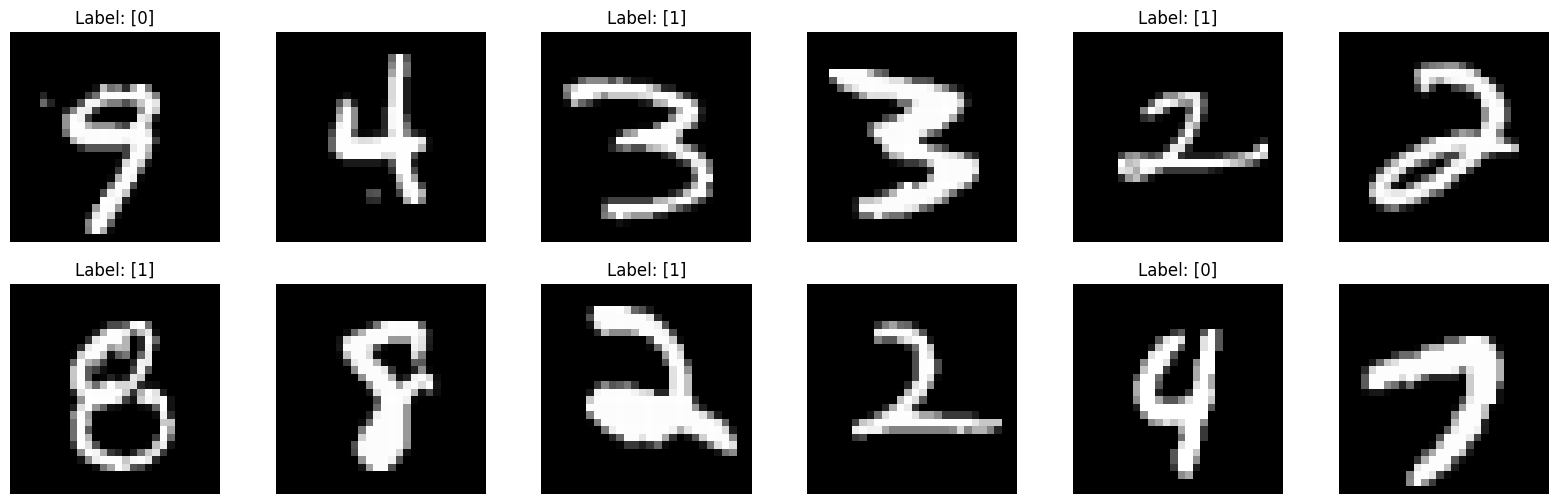

In [109]:
fig, ax = plt.subplots(2, 6, figsize=(20, 6))
for i in range(0,12,2):
    ax[i//6][i%6].imshow(train_images[i//2][0].transpose(1,2,0), cmap='gray')
    ax[i//6][i%6+1].imshow(train_images[i//2][1].transpose(1,2,0), cmap='gray')
    ax[i//6][i%6].set_title(f'Label: {train_labels[i//2]}')
    ax[i//6][i%6].set_axis_off()
    ax[i//6][i%6+1].set_axis_off()

Converting to tensor form

In [110]:
train_images, train_labels = torch.tensor(train_images), torch.tensor(train_labels)
val_images, val_labels = torch.tensor(val_images), torch.tensor(val_labels)
test_images, test_labels = torch.tensor(test_images), torch.tensor(test_labels)

In [184]:
from torch.utils.data import TensorDataset

In [185]:
train_dataset = TensorDataset(train_images, train_labels)
val_dataset = TensorDataset(val_images, val_labels)
test_dataset = TensorDataset(test_images, test_labels)

In [186]:
train_dl = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dl = DataLoader(val_dataset, batch_size=64)
test_dl = DataLoader(test_dataset, batch_size=64)

In [190]:
for i,j in train_dl:
    print(i.shape)
    print(j.shape)
    break

torch.Size([64, 2, 1, 28, 28])
torch.Size([64, 1])


In [111]:
epochs = 500
embedding_dim = 48
img_shape = (28,28,1)

Define a function to compute the euclidean distance between 2 vectors.. this will be used bu the model to compute the euclidean distance between the vector of the image pairs. (image vectors will be created by the model's feature extractor -> conv layer)

In [173]:
import torch.nn.functional as F

In [176]:
class EuclideanDistance(nn.Module):
    def __init__(self, eps: float = 1e-8):
        super().__init__()
        self.eps = eps
    
    def forward(self, vec1, vec2):
        sumSquared = torch.sum(torch.square(vec1 - vec2), dim=1, keepdim = True)
        return torch.sqrt(sumSquared + self.eps)

In [213]:
class SiameseNetwork(nn.Module):
    def __init__(self, embeddingdim):
        super().__init__()
        self.featureExtractor = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=2, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=2, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=1, padding="same"),
            nn.ReLU(),
            # nn.Dropout2d(0.2)
        )
        self.fc1 = nn.Linear(6272, embeddingdim)

        self.fc2 = nn.Linear(1, 1)
        nn.init.constant_(self.fc2.weight, -1)
        nn.init.constant_(self.fc2.bias, 0)

        self.distance_comp = EuclideanDistance()
    
    def forward(self, img1, img2):
        featsA, featsB = F.relu(self.featureExtractor(img1)), F.relu(self.featureExtractor(img2))
        featsA, featsB = featsA.view(img1.shape[0],-1), featsB.view(img2.shape[0],-1)
        featsA, featsB = F.relu(self.fc1(featsA)), F.relu(self.fc1(featsB))
        distance = self.distance_comp(featsA, featsB)
        out = self.fc2(distance)
        return out

In [214]:
from utils.early_stopping import EarlyStopping

In [215]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
model = SiameseNetwork(48).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# get a scheduler to reduce the learning rate on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',patience=5)

early_stopper = EarlyStopping(
    patience=10,
    min_delta=0.001,
    checkpoint_path='siamese1.pt',
    restore_best_weights=True
)

In [216]:
# write the training loop

def train(epochs):
    train_loss = [0] * epochs
    train_acc = [0] * epochs
    val_loss = [0] * epochs
    val_acc = [0] * epochs

    for epoch in range(epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            x_batch , y_batch = x_batch.to(device), y_batch.to(device)
            # forward pass
            img1, img2 = x_batch[:, 0], x_batch[:, 1]
            logits = model(img1, img2)
            # compute the loss
            loss = criterion(logits, y_batch.float())
            # back propagation
            loss.backward()
            # optimization
            optimizer.step()
            # zero grad
            optimizer.zero_grad()

            train_loss[epoch]+= loss.item() * y_batch.shape[0]

            train_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
        
        train_loss[epoch] /= len(train_dl.dataset)
        train_acc[epoch] /= len(train_dl.dataset)

        # evaluation
        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in val_dl:
                x_batch , y_batch = x_batch.to(device), y_batch.to(device)
                img1, img2 = x_batch[:,0], x_batch[:,1]
                # forward pass
                logits = model(img1, img2)
                loss = criterion(logits, y_batch.float())

                val_loss[epoch] += loss.item() * y_batch.shape[0]

                val_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
            
            val_loss[epoch] /= len(val_dl.dataset)
            val_acc[epoch] /= len(val_dl.dataset)
        
        print(f"Epoch: {epoch+1} | Train Acc: {train_acc[epoch]} | Train Loss: {train_loss[epoch]} | Val Acc: {val_acc[epoch]} | Val Loss: {val_loss[epoch]}")

        scheduler.step(val_loss[epoch])
        early_stopper(val_loss[epoch], model, optimizer, epoch)

        if early_stopper.should_stop:
            break
    return train_loss, train_acc, val_loss, val_acc

In [217]:
hist = train(500)

Epoch: 1 | Train Acc: 0.9046770930290222 | Train Loss: 0.2607102709611257 | Val Acc: 0.9452499747276306 | Val Loss: 0.15390122520923616
Metric improved to 0.1539. Checkpoint saved at 0
Epoch: 2 | Train Acc: 0.9588021039962769 | Train Loss: 0.11843375795086225 | Val Acc: 0.9635000228881836 | Val Loss: 0.10111081552505494
Metric improved to 0.1011. Checkpoint saved at 1
Epoch: 3 | Train Acc: 0.96463543176651 | Train Loss: 0.09746586242814859 | Val Acc: 0.953166663646698 | Val Loss: 0.12349999246994654
No improvement for 1 epoch(s)
Epoch: 4 | Train Acc: 0.9701145887374878 | Train Loss: 0.08158776394464076 | Val Acc: 0.9701666831970215 | Val Loss: 0.08191865687817335
Metric improved to 0.0819. Checkpoint saved at 3
Epoch: 5 | Train Acc: 0.9739791750907898 | Train Loss: 0.07158275677046429 | Val Acc: 0.9739166498184204 | Val Loss: 0.07104232266545296
Metric improved to 0.0710. Checkpoint saved at 4
Epoch: 6 | Train Acc: 0.9772291779518127 | Train Loss: 0.06329270545238008 | Val Acc: 0.97883

Predictions on the test set

In [218]:
import random

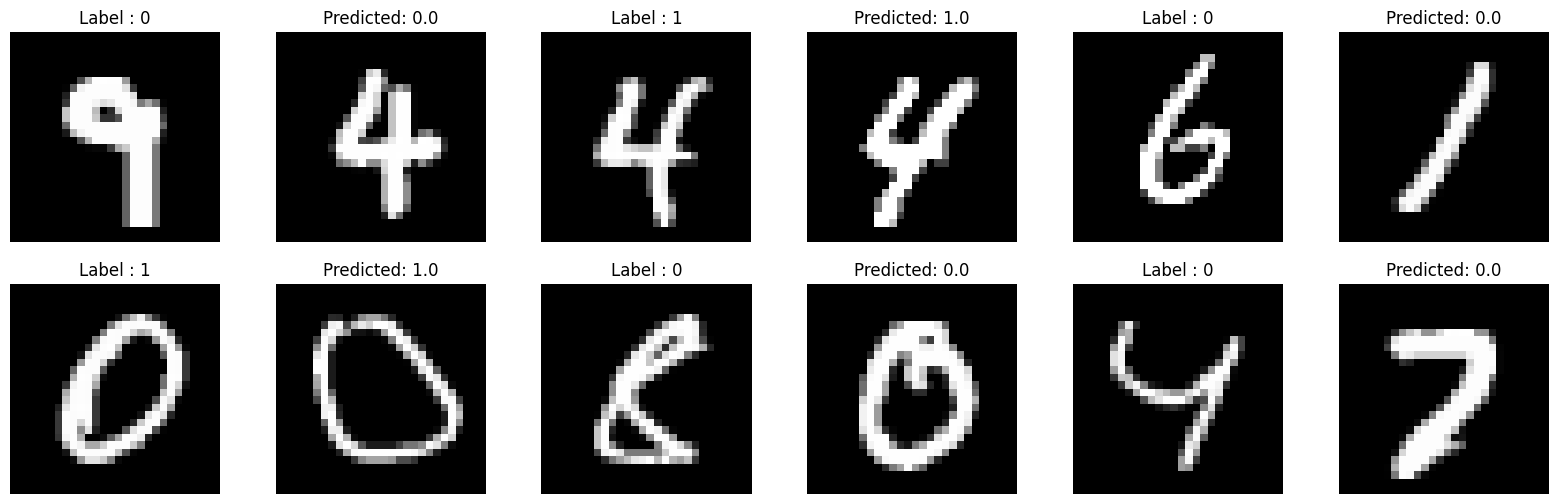

In [247]:
fig, ax = plt.subplots(2,6, figsize=(20,6))
random.seed(19)
idx = random.choices(range(len(test_dataset)), k=6)
im, lab = test_dataset[idx]
im_ = im.to(device)
model.eval()
with torch.no_grad():
    preds = model(im_[:,0], im_[:,1])
    preds = (F.sigmoid(preds.squeeze()) >= 0.5).float()
    preds = preds.clone().cpu().numpy()
    lab = lab.clone().squeeze().numpy()

for i in range(0, 12, 2):
    ax[i//6][i%6].imshow(im[i//2][0].permute(1,2,0).numpy(), cmap='gray')
    ax[i//6][i%6+1].imshow(im[i//2][1].permute(1,2,0).numpy(), cmap='gray')
    ax[i//6][i%6].set_title(f"Label : {lab[i//2]}")
    ax[i//6][i%6+1].set_title(f'Predicted: {preds[i//2]}')
    ax[i//6][i%6].set_axis_off()
    ax[i//6][i%6+1].set_axis_off()

Tweak 1..using cosine similarity instead of euclidean distances

In [272]:
a , b = torch.randn((64,48)), torch.randn((64,48))

In [276]:
F.cosine_similarity(a,b, dim=1)

tensor([-0.0851, -0.1603,  0.1422,  0.0765,  0.0572,  0.3985,  0.1510,  0.1395,
         0.0189,  0.4327,  0.0138, -0.1702, -0.0242, -0.0961, -0.0216, -0.0063,
        -0.0571,  0.0045, -0.0991, -0.1094, -0.0373, -0.1848,  0.1582, -0.2015,
        -0.1588,  0.0460, -0.0430,  0.2443,  0.0323, -0.0060, -0.1655, -0.0959,
         0.0409, -0.2886, -0.0247, -0.0041, -0.2026, -0.1603,  0.1055,  0.1561,
         0.0314,  0.0066,  0.1282,  0.1255,  0.0741, -0.1087, -0.0110,  0.0580,
         0.0180, -0.1410, -0.0365,  0.1921, -0.1220, -0.0546,  0.0068,  0.1601,
        -0.0648,  0.1802,  0.0350, -0.1661,  0.0234, -0.2164,  0.2220, -0.1226])

In [279]:
F.cosine_similarity(a,b, dim=1).unsqueeze(1).shape

torch.Size([64, 1])

In [277]:
1 - F.cosine_similarity(a,b, dim=1)

tensor([1.0851, 1.1603, 0.8578, 0.9235, 0.9428, 0.6015, 0.8490, 0.8605, 0.9811,
        0.5673, 0.9862, 1.1702, 1.0242, 1.0961, 1.0216, 1.0063, 1.0571, 0.9955,
        1.0991, 1.1094, 1.0373, 1.1848, 0.8418, 1.2015, 1.1588, 0.9540, 1.0430,
        0.7557, 0.9677, 1.0060, 1.1655, 1.0959, 0.9591, 1.2886, 1.0247, 1.0041,
        1.2026, 1.1603, 0.8945, 0.8439, 0.9686, 0.9934, 0.8718, 0.8745, 0.9259,
        1.1087, 1.0110, 0.9420, 0.9820, 1.1410, 1.0365, 0.8079, 1.1220, 1.0546,
        0.9932, 0.8399, 1.0648, 0.8198, 0.9650, 1.1661, 0.9766, 1.2164, 0.7780,
        1.1226])

In [286]:
class SiameseNetwork2(nn.Module):
    def __init__(self, embeddingdim):
        super().__init__()
        self.featureExtractor = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=2, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=2, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=1, padding="same"),
            nn.ReLU(),
            # nn.Dropout2d(0.2)
        )
        self.fc1 = nn.Linear(6272, embeddingdim)

        self.fc2 = nn.Linear(1, 1)
        nn.init.constant_(self.fc2.weight, -1)
        nn.init.constant_(self.fc2.bias, 0)

    
    def forward(self, img1, img2):
        featsA, featsB = F.relu(self.featureExtractor(img1)), F.relu(self.featureExtractor(img2))
        featsA, featsB = featsA.view(img1.shape[0],-1), featsB.view(img2.shape[0],-1)
        featsA, featsB = F.relu(self.fc1(featsA)), F.relu(self.fc1(featsB))
        distance = (1 - F.cosine_similarity(featsA, featsB, dim=1)).unsqueeze(1)
        out = self.fc2(distance)
        return out

In [ ]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
model2 = SiameseNetwork2(48).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.01)

# get a scheduler to reduce the learning rate on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',patience=5)

early_stopper = EarlyStopping(
    patience=10,
    min_delta=0.001,
    checkpoint_path='siamese2.pt',
    restore_best_weights=True
)

# write the training loop

def train(epochs):
    train_loss = [0] * epochs
    train_acc = [0] * epochs
    val_loss = [0] * epochs
    val_acc = [0] * epochs

    for epoch in range(epochs):
        model2.train()
        for x_batch, y_batch in train_dl:
            x_batch , y_batch = x_batch.to(device), y_batch.to(device)
            # forward pass
            img1, img2 = x_batch[:, 0], x_batch[:, 1]
            logits = model2(img1, img2)
            # compute the loss
            loss = criterion(logits, y_batch.float())
            # back propagation
            loss.backward()
            # optimization
            optimizer.step()
            # zero grad
            optimizer.zero_grad()

            train_loss[epoch]+= loss.item() * y_batch.shape[0]

            train_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
        
        train_loss[epoch] /= len(train_dl.dataset)
        train_acc[epoch] /= len(train_dl.dataset)

        # evaluation
        model2.eval()
        with torch.no_grad():
            for x_batch, y_batch in val_dl:
                x_batch , y_batch = x_batch.to(device), y_batch.to(device)
                img1, img2 = x_batch[:,0], x_batch[:,1]
                # forward pass
                logits = model2(img1, img2)
                loss = criterion(logits, y_batch.float())

                val_loss[epoch] += loss.item() * y_batch.shape[0]

                val_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
            
            val_loss[epoch] /= len(val_dl.dataset)
            val_acc[epoch] /= len(val_dl.dataset)
        
        print(f"Epoch: {epoch+1} | Train Acc: {train_acc[epoch]} | Train Loss: {train_loss[epoch]} | Val Acc: {val_acc[epoch]} | Val Loss: {val_loss[epoch]}")

        scheduler.step(val_loss[epoch])
        early_stopper(val_loss[epoch], model2, optimizer, epoch)

        if early_stopper.should_stop:
            break
    return train_loss, train_acc, val_loss, val_acc

In [288]:
hist = train(500)

Epoch: 1 | Train Acc: 0.90234375 | Train Loss: 0.2728260858679811 | Val Acc: 0.9430000185966492 | Val Loss: 0.16692919667561848
Metric improved to 0.1669. Checkpoint saved at 0
Epoch: 2 | Train Acc: 0.9518125057220459 | Train Loss: 0.13959554515530664 | Val Acc: 0.9649166464805603 | Val Loss: 0.10299629656473795
Metric improved to 0.1030. Checkpoint saved at 1
Epoch: 3 | Train Acc: 0.9722708463668823 | Train Loss: 0.08866888149455189 | Val Acc: 0.9745000004768372 | Val Loss: 0.08387279903888703
Metric improved to 0.0839. Checkpoint saved at 2
Epoch: 4 | Train Acc: 0.9783437252044678 | Train Loss: 0.06810031381746133 | Val Acc: 0.9773333072662354 | Val Loss: 0.06679784409701824
Metric improved to 0.0668. Checkpoint saved at 3
Epoch: 5 | Train Acc: 0.9830937385559082 | Train Loss: 0.05385424990238001 | Val Acc: 0.981083333492279 | Val Loss: 0.05450017129381498
Metric improved to 0.0545. Checkpoint saved at 4
Epoch: 6 | Train Acc: 0.9864166378974915 | Train Loss: 0.04356295579299331 | Val

cosine distance works really well

In [292]:
train_loss, train_acc, val_loss, val_acc = hist[0][:29], hist[1][:29], hist[2][:29], hist[3][:29]

In [294]:
train_acc = list(map(lambda x: x.item(), train_acc))
val_acc = list(map(lambda x: x.item(), val_acc))

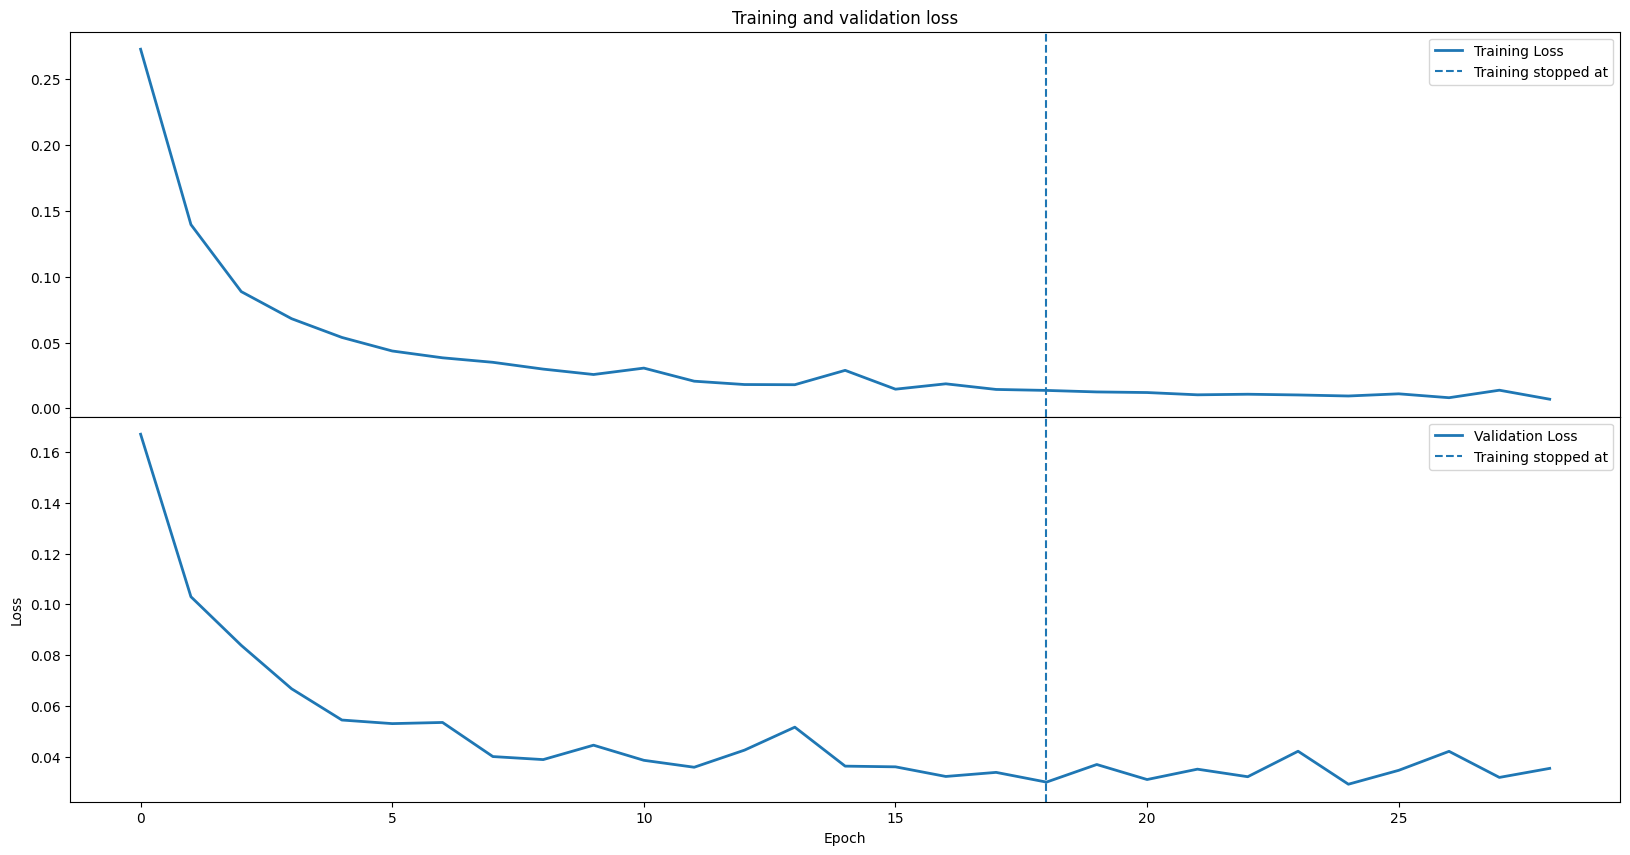

In [303]:
fig, ax = plt.subplots(2,1,figsize=(20,10),sharex=True)
fig.subplots_adjust(hspace=0)
ax[0].plot(train_loss, label="Training Loss", linewidth=2)
ax[1].plot(val_loss, label="Validation Loss", linewidth=2)
ax[0].axvline(x=18, linestyle="--",linewidth=1.5,label=f"Training stopped at")
ax[1].axvline(x=18, linestyle="--",linewidth=1.5,label=f"Training stopped at")
ax[0].set_title("Training and validation loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[0].legend()
ax[1].legend()

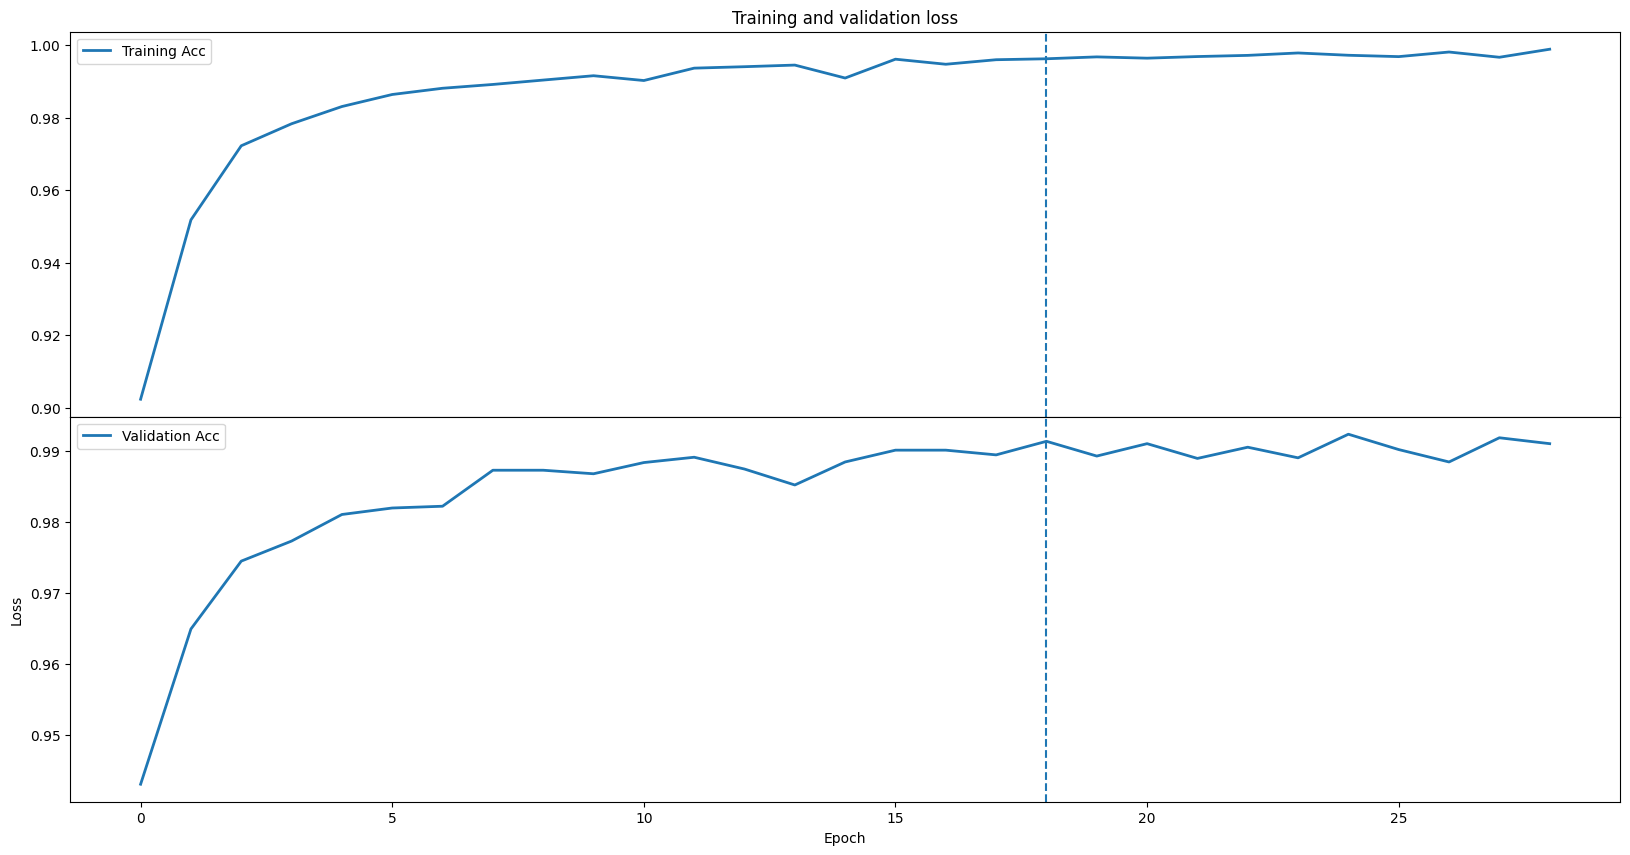

In [305]:
fig, ax = plt.subplots(2,1,figsize=(20,10),sharex=True)
fig.subplots_adjust(hspace=0)
ax[0].plot(train_acc, label="Training Acc", linewidth=2)
ax[1].plot(val_acc, label="Validation Acc", linewidth=2)
ax[0].axvline(x=18, linestyle="--",linewidth=1.5)
ax[1].axvline(x=18, linestyle="--",linewidth=1.5)
ax[0].set_title("Training and validation loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[0].legend()
ax[1].legend()

**BCE trains the Siamese network as a binary pair classifier. on the other hand, losses such as contrastive, cosine embedding, and triplet loss instead train the geometry if the embedding space directly**
- main distinction:
  - BCE: images -> embeddings -> comparison score (euclidean or cosine) -> classifier -> same/different probability
  - Metric-learning loss:
    - images -> embeddings -> directly pull similar samples together and push dissimialr samples apart

- for metric-learning losses, the model should udually expose an embedding function rather than returning a final sigmoid probability 

**Refactoring the model to return embeddings**

In [314]:
class SiameseNetwork3(nn.Module):
    def __init__(self, embeddingdim: int):
        super().__init__()
        self.featureExtractor = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=64, kernel_size=2, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=2, padding="same"),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # nn.Dropout2d(0.3),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=1, padding="same"),
            nn.ReLU(),
            # nn.Dropout2d(0.2)
        )
        self.fc1 = nn.Linear(6272, embeddingdim)
    
    def forward(self, img1, img2):
        featsA, featsB = F.relu(self.featureExtractor(img1)), F.relu(self.featureExtractor(img2))
        featsA, featsB = featsA.view(img1.shape[0],-1), featsB.view(img2.shape[0],-1)
        featsA, featsB = self.fc1(featsA), self.fc1(featsB)
        # returning embeddings instead
        return featsA, featsB

Cosine Embedding Loss

In [309]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
model3 = SiameseNetwork3(48).to(device)
criterion = nn.CosineEmbeddingLoss()
optimizer = torch.optim.Adam(model3.parameters(), lr=0.01)

# get a scheduler to reduce the learning rate on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',patience=5)

early_stopper = EarlyStopping(
    patience=10,
    min_delta=0.001,
    checkpoint_path='siamese3.pt',
    restore_best_weights=True
)

# write the training loop

def train(epochs):
    train_loss = [0] * epochs
    #train_acc = [0] * epochs
    val_loss = [0] * epochs
    #val_acc = [0] * epochs

    for epoch in range(epochs):
        model3.train()
        for x_batch, y_batch in train_dl:
            x_batch , y_batch = x_batch.to(device), y_batch.to(device)
            # forward pass
            img1, img2 = x_batch[:, 0], x_batch[:, 1]
            embedding1, embedding2 = model3(img1, img2)
            # generate cosine targets
            cosine_targets = torch.where(
                y_batch == 1,
                torch.ones_like(y_batch, dtype=torch.float32),
                -torch.ones_like(y_batch, dtype=torch.float32),
            )
            # compute the loss
            loss = criterion(embedding1, embedding2, cosine_targets.squeeze())
            # back propagation
            loss.backward()
            # optimization
            optimizer.step()
            # zero grad
            optimizer.zero_grad()

            train_loss[epoch]+= loss.item() * y_batch.shape[0]

            #train_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
        
        train_loss[epoch] /= len(train_dl.dataset)
        #train_acc[epoch] /= len(train_dl.dataset)

        # evaluation
        model3.eval()
        with torch.no_grad():
            for x_batch, y_batch in val_dl:
                x_batch , y_batch = x_batch.to(device), y_batch.to(device)
                img1, img2 = x_batch[:,0], x_batch[:,1]
                # forward pass
                embedding1, embedding2 = model3(img1, img2)
                cosine_targets = torch.where(
                                        y_batch == 1,
                                        torch.ones_like(y_batch, dtype=torch.float32),
                                        -torch.ones_like(y_batch, dtype=torch.float32),
                                    )
                loss = criterion(embedding1, embedding2, cosine_targets.squeeze())

                val_loss[epoch] += loss.item() * y_batch.shape[0]

                #val_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
            
            val_loss[epoch] /= len(val_dl.dataset)
            #val_acc[epoch] /= len(val_dl.dataset)
        
        print(f"Epoch: {epoch+1} | Train Loss: {train_loss[epoch]} | Val Loss: {val_loss[epoch]}")

        scheduler.step(val_loss[epoch])
        early_stopper(val_loss[epoch], model3, optimizer, epoch)

        if early_stopper.should_stop:
            break
    return train_loss, val_loss

In [310]:
hist = train(500)

Epoch: 1 | Train Loss: 0.12835347683231035 | Val Loss: 0.08979244271914165
Metric improved to 0.0898. Checkpoint saved at 0
Epoch: 2 | Train Loss: 0.08093588131045301 | Val Loss: 0.07599008371432622
Metric improved to 0.0760. Checkpoint saved at 1
Epoch: 3 | Train Loss: 0.07139040889342627 | Val Loss: 0.06779383739829063
Metric improved to 0.0678. Checkpoint saved at 2
Epoch: 4 | Train Loss: 0.06570167351638277 | Val Loss: 0.06521213151017825
Metric improved to 0.0652. Checkpoint saved at 3
Epoch: 5 | Train Loss: 0.06251666173711419 | Val Loss: 0.06316436645388603
Metric improved to 0.0632. Checkpoint saved at 4
Epoch: 6 | Train Loss: 0.058984328979005414 | Val Loss: 0.05934905431667964
Metric improved to 0.0593. Checkpoint saved at 5
Epoch: 7 | Train Loss: 0.0556892861785988 | Val Loss: 0.056929227421681085
Metric improved to 0.0569. Checkpoint saved at 6
Epoch: 8 | Train Loss: 0.05304843059368432 | Val Loss: 0.05448121819893519
Metric improved to 0.0545. Checkpoint saved at 7
Epoch: 

cosine embedding loss works fine too

**Contrastive Loss**

In [315]:
# custom implementation of the contrastive loss
class ContrastiveLoss(nn.Module):
    def __init__(self, margin:float=1.0):
        super().__init__()

        if margin <= 0:
            raise ValueError("margin must be positive")
        
        self.margin = margin
    
    def forward(self, embedding1: torch.Tensor, embedding2:torch.Tensor, targets:torch.Tensor)->torch.Tensor:
        # converting the targets to floats and flattening
        targets = targets.float().view(-1)

        # computing the euclidean distances between 2 vectors
        distances = F.pairwise_distance(
            embedding1,
            embedding2,
            p=2
        )
        # positive loss of the contrastive loss
        positive_loss = targets * distances.square()

        # negative loss
        negative_loss = (
            1.0 - targets
        ) * F.relu(self.margin - distances).square()

        return (positive_loss + negative_loss).mean()

Training with the contrastive loss

In [316]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
model3 = SiameseNetwork3(48).to(device)
criterion = ContrastiveLoss(margin=1.0)
optimizer = torch.optim.Adam(model3.parameters(), lr=0.01)

# get a scheduler to reduce the learning rate on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',patience=5)

early_stopper = EarlyStopping(
    patience=10,
    min_delta=0.001,
    checkpoint_path='siamese3.pt',
    restore_best_weights=True
)

# write the training loop

def train(epochs):
    train_loss = [0] * epochs
    #train_acc = [0] * epochs
    val_loss = [0] * epochs
    #val_acc = [0] * epochs

    for epoch in range(epochs):
        model3.train()
        for x_batch, y_batch in train_dl:
            x_batch , y_batch = x_batch.to(device), y_batch.to(device)
            # forward pass
            img1, img2 = x_batch[:, 0], x_batch[:, 1]
            embedding1, embedding2 = model3(img1, img2)
            
            # compute the loss
            loss = criterion(embedding1, embedding2, y_batch)
            # back propagation
            loss.backward()
            # optimization
            optimizer.step()
            # zero grad
            optimizer.zero_grad()

            train_loss[epoch]+= loss.item() * y_batch.shape[0]

            #train_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
        
        train_loss[epoch] /= len(train_dl.dataset)
        #train_acc[epoch] /= len(train_dl.dataset)

        # evaluation
        model3.eval()
        with torch.no_grad():
            for x_batch, y_batch in val_dl:
                x_batch , y_batch = x_batch.to(device), y_batch.to(device)
                img1, img2 = x_batch[:,0], x_batch[:,1]
                # forward pass
                embedding1, embedding2 = model3(img1, img2)

                loss = criterion(embedding1, embedding2, y_batch)

                val_loss[epoch] += loss.item() * y_batch.shape[0]

                #val_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
            
            val_loss[epoch] /= len(val_dl.dataset)
            #val_acc[epoch] /= len(val_dl.dataset)
        
        print(f"Epoch: {epoch+1} | Train Loss: {train_loss[epoch]} | Val Loss: {val_loss[epoch]}")

        scheduler.step(val_loss[epoch])
        early_stopper(val_loss[epoch], model3, optimizer, epoch)

        if early_stopper.should_stop:
            break
    return train_loss, val_loss


In [317]:
hist = train(500)

Epoch: 1 | Train Loss: 0.10476018527150154 | Val Loss: 0.09247482651472091
Metric improved to 0.0925. Checkpoint saved at 0
Epoch: 2 | Train Loss: 0.09711430147538583 | Val Loss: 0.10249023667971294
No improvement for 1 epoch(s)
Epoch: 3 | Train Loss: 0.10232978068043788 | Val Loss: 0.10200756412744522
No improvement for 2 epoch(s)
Epoch: 4 | Train Loss: 0.09841773031403621 | Val Loss: 0.0963344111641248
No improvement for 3 epoch(s)
Epoch: 5 | Train Loss: 0.09794640626013279 | Val Loss: 0.09432119679450988
No improvement for 4 epoch(s)
Epoch: 6 | Train Loss: 0.09745433496683836 | Val Loss: 0.09847567417224248
No improvement for 5 epoch(s)
Epoch: 7 | Train Loss: 0.09720177042235931 | Val Loss: 0.09851662840445836
No improvement for 6 epoch(s)
Epoch: 8 | Train Loss: 0.0878035364250342 | Val Loss: 0.08682917932669322
Metric improved to 0.0868. Checkpoint saved at 7
Epoch: 9 | Train Loss: 0.08673956191043058 | Val Loss: 0.08629353392124176
No improvement for 1 epoch(s)
Epoch: 10 | Train L

Cosine version of the contrastive loss:

In [318]:
class CosineContrastiveLoss(nn.Module):
    def __init__(self, margin:float=0.5):
        super().__init__()
        self.margin = margin
    
    def forward(self, embedding1, embedding2, targets):
        targets = targets.float().view(-1)

        similarity = F.cosine_similarity(
            embedding1,
            embedding2,
            dim=1
        )
        cosine_distance = 1.0 - similarity
        positive_loss = targets * cosine_distance.square()

        negative_loss = (
            1.0 - targets
        ) * F.relu(
            self.margin - cosine_distance
        ).square()

        return (positive_loss + negative_loss).mean()

In [319]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
model3 = SiameseNetwork3(48).to(device)
criterion = CosineContrastiveLoss(margin=0.5)
optimizer = torch.optim.Adam(model3.parameters(), lr=0.01)

# get a scheduler to reduce the learning rate on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,'min',patience=5)

early_stopper = EarlyStopping(
    patience=10,
    min_delta=0.001,
    checkpoint_path='siamese3.pt',
    restore_best_weights=True
)

# write the training loop

def train(epochs):
    train_loss = [0] * epochs
    #train_acc = [0] * epochs
    val_loss = [0] * epochs
    #val_acc = [0] * epochs

    for epoch in range(epochs):
        model3.train()
        for x_batch, y_batch in train_dl:
            x_batch , y_batch = x_batch.to(device), y_batch.to(device)
            # forward pass
            img1, img2 = x_batch[:, 0], x_batch[:, 1]
            embedding1, embedding2 = model3(img1, img2)
            
            # compute the loss
            loss = criterion(embedding1, embedding2, y_batch)
            # back propagation
            loss.backward()
            # optimization
            optimizer.step()
            # zero grad
            optimizer.zero_grad()

            train_loss[epoch]+= loss.item() * y_batch.shape[0]

            #train_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
        
        train_loss[epoch] /= len(train_dl.dataset)
        #train_acc[epoch] /= len(train_dl.dataset)

        # evaluation
        model3.eval()
        with torch.no_grad():
            for x_batch, y_batch in val_dl:
                x_batch , y_batch = x_batch.to(device), y_batch.to(device)
                img1, img2 = x_batch[:,0], x_batch[:,1]
                # forward pass
                embedding1, embedding2 = model3(img1, img2)

                loss = criterion(embedding1, embedding2, y_batch)

                val_loss[epoch] += loss.item() * y_batch.shape[0]

                #val_acc[epoch] += ((F.sigmoid(logits.squeeze()) >= 0.5).float() == y_batch.float().squeeze()).float().sum()
            
            val_loss[epoch] /= len(val_dl.dataset)
            #val_acc[epoch] /= len(val_dl.dataset)
        
        print(f"Epoch: {epoch+1} | Train Loss: {train_loss[epoch]} | Val Loss: {val_loss[epoch]}")

        scheduler.step(val_loss[epoch])
        early_stopper(val_loss[epoch], model3, optimizer, epoch)

        if early_stopper.should_stop:
            break
    return train_loss, val_loss


In [320]:
hist = train(500)

Epoch: 1 | Train Loss: 0.02076602024383222 | Val Loss: 0.008696859177201987
Metric improved to 0.0087. Checkpoint saved at 0
Epoch: 2 | Train Loss: 0.007588254317641258 | Val Loss: 0.006331974815577269
Metric improved to 0.0063. Checkpoint saved at 1
Epoch: 3 | Train Loss: 0.005862646635932227 | Val Loss: 0.005581989928459128
No improvement for 1 epoch(s)
Epoch: 4 | Train Loss: 0.00498226832303529 | Val Loss: 0.004740846508493026
Metric improved to 0.0047. Checkpoint saved at 3
Epoch: 5 | Train Loss: 0.00442152367454643 | Val Loss: 0.004554706832394004
No improvement for 1 epoch(s)
Epoch: 6 | Train Loss: 0.0040258748503789925 | Val Loss: 0.004398029272754987
No improvement for 2 epoch(s)
Epoch: 7 | Train Loss: 0.0036879501555813475 | Val Loss: 0.004026603772615393
No improvement for 3 epoch(s)
Epoch: 8 | Train Loss: 0.003475084821965235 | Val Loss: 0.0038023418094962837
No improvement for 4 epoch(s)
Epoch: 9 | Train Loss: 0.0032444232416261607 | Val Loss: 0.003867392764116327
No improv